 Praktikum 14 – Kubische Splines
Aufgabe 1 – Natürliche kubische Splineinterpolation

Gegeben ist die Funktion

$$
f(x)=\frac{1}{1+x^2}
$$

im Intervall ([-5,5]).

Für (n=6,;9,;15) werden äquidistant verteilte Punkte berechnet und mit natürlichen kubischen Splines interpoliert.

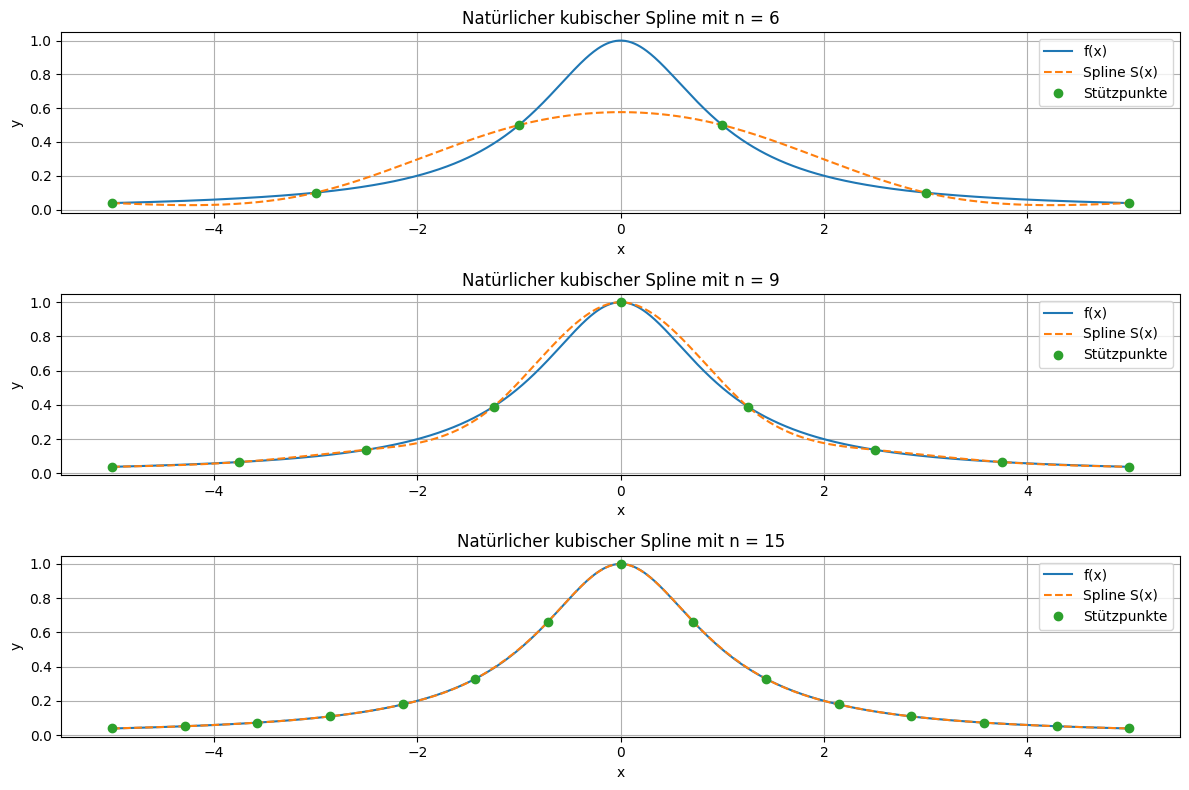

In [9]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Funktion definieren
def f(x):
    return 1 / (1 + x**2)

# Werte für n
n_values = [6, 9, 15]

# Fein aufgelöste x-Werte für Plot
x_fine = np.linspace(-5, 5, 1000)

plt.figure(figsize=(12, 8))

for i, n in enumerate(n_values, 1):

    # äquidistante Punkte
    x = np.linspace(-5, 5, n)
    y = f(x)

    # natürlicher kubischer Spline
    spline = CubicSpline(x, y, bc_type='natural')

    # Splinewerte
    y_spline = spline(x_fine)

    # Plot
    plt.subplot(3, 1, i)
    plt.plot(x_fine, f(x_fine), label='f(x)')
    plt.plot(x_fine, y_spline, '--', label='Spline S(x)')
    plt.plot(x, y, 'o', label='Stützpunkte')

    plt.title(f'Natürlicher kubischer Spline mit n = {n}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

## Aufgabe 2 – Anwendung in der Robotersteuerung

Gegeben sind Zeit- und Positionswerte:

t = [0, 2, 4, 6, 8, 10, 12, 14, 16]

x = [-50, 200, 500, 750, 1000, 750, 500, 200, -50]

y = [200, 0, 250, 500, 250, 0, 250, 500, 200]
`

Zur Beschreibung der Bewegung werden zwei Splinefunktionen verwendet:

$$
S_x(t), \qquad S_y(t)
$$

Da Start- und Endpunkt identisch sind, eignet sich eine **periodische Randbedingung**, um eine glatte geschlossene Bewegungskurve zu erhalten.


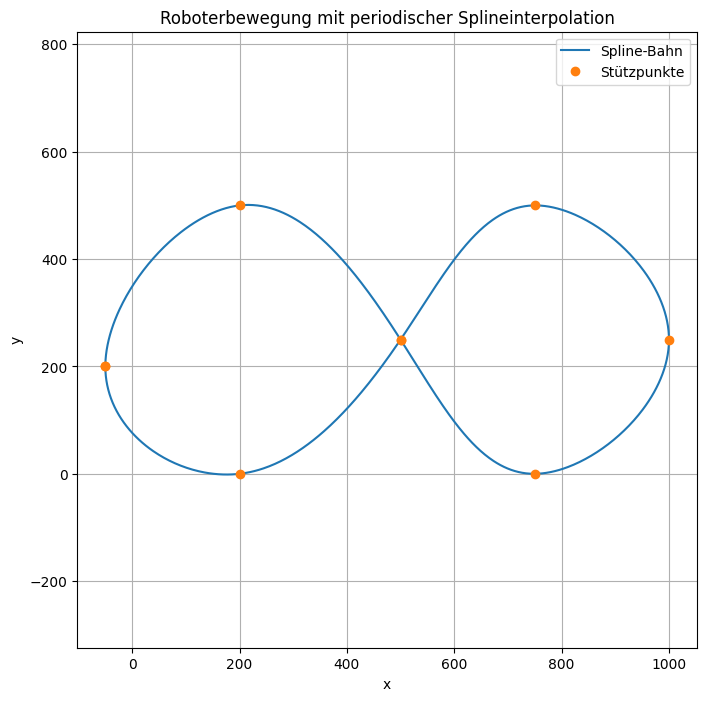

In [ ]:
# Vorgabedaten
t = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16])

x = np.array([-50, 200, 500, 750, 1000, 750, 500, 200, -50])

y = np.array([200, 0, 250, 500, 250, 0, 250, 500, 200])

# Periodische kubische Splines
sx = CubicSpline(t, x, bc_type='periodic')
sy = CubicSpline(t, y, bc_type='periodic')

# Fein aufgelöste Zeitwerte
t_fine = np.linspace(0, 16, 1000)

# Interpolierte Kurve
x_fine = sx(t_fine)
y_fine = sy(t_fine)

# Plot
plt.figure(figsize=(8, 8))

plt.plot(x_fine, y_fine, label='Spline-Bahn')
plt.plot(x, y, 'o', label='Stützpunkte')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Roboterbewegung mit periodischer Splineinterpolation')

plt.axis('equal')
plt.grid(True)
plt.legend()

plt.show()